# 04. HMM 레짐 탐지 — 수도권 아파트 시장 국면 전환

- **방법**: Gaussian HMM (hmmlearn) — 숨겨진 시장 국면(정상·과열·버블) 탐지
- **입력**: `data/processed/lstm_ae_scores.csv` (468행 × 45컬럼)
- **피처**: 7개 (가격YoY, 전세가율, PIR, 금리, 변동성, BSI, LSTM재구성오차)
- **구조**: 시도별 독립 HMM → 상태 수 BIC 최적화 → 국면 이름 매핑
- **출력**:
  - `data/processed/hmm_regime.csv` — 월별 HMM 상태 + 국면 이름
  - `notebooks/fig_hmm_01~05.png`

In [1]:
import warnings, os
warnings.filterwarnings('ignore')
os.chdir('c:/Users/bko05/Desktop/seoul-bubble-detection')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.ticker as mticker
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix
from hmmlearn.hmm import GaussianHMM

plt.rcParams['font.family']        = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus']  = False
plt.rcParams['figure.dpi']          = 110

SEED       = 42
ENC        = 'utf-8-sig'
SIDO_LIST  = ['서울', '경기', '인천']
SIDO_COLORS = {'서울': '#E63946', '경기': '#2A9D8F', '인천': '#E9C46A'}
np.random.seed(SEED)

print(f'hmmlearn 준비 완료')

hmmlearn 준비 완료


---
## 1. 데이터 준비 & 피처 선택

In [2]:
df = pd.read_csv('data/processed/lstm_ae_scores.csv', encoding=ENC)
df['ym_dt'] = pd.to_datetime(df['ym'].astype(str), format='%Y%m')

# ── HMM 피처: 7개 (가격·전세·소득·금리·변동성·심리·이상탐지)
HMM_FEATURES = [
    '매매중위_YoY',     # 가격 상승률 — 버블 핵심 신호
    '전세가율',         # 전세가율 — 버블: 하락, 정상: 상승
    'PIR',             # 가격/소득 — 과열 지표
    'base_rate',       # 기준금리 — 거시 환경
    '매매_vol12',       # 12개월 가격 변동성 — 불안정성
    'bsi_realestate',  # 부동산업 BSI — 시장 심리
    'recon_error',     # LSTM-AE 재구성 오차 — 이상 점수 연계
]

# ── 결측 처리: 초기 12개월 NaN → 시도별 ffill → bfill (pandas 2.x 호환)
df_hmm = df.copy().sort_values(['시도', 'ym']).reset_index(drop=True)
for sido in SIDO_LIST:
    mask = df_hmm['시도'] == sido
    df_hmm.loc[mask, HMM_FEATURES] = (
        df_hmm.loc[mask, HMM_FEATURES].ffill().bfill().values
    )

print(f'전체 행: {len(df_hmm)}')
print(f'결측 처리 후 NaN: {df_hmm[HMM_FEATURES].isnull().sum().sum()}개')
print()
print('피처 기술통계:')
print(df_hmm[HMM_FEATURES].describe().T[['mean','std','min','max']].round(3))

전체 행: 468
결측 처리 후 NaN: 0개

피처 기술통계:
                  mean     std     min      max
매매중위_YoY         7.639  11.892 -35.484   58.333
전세가율            70.271   9.715  45.900  103.230
PIR              6.160   2.846   3.480   14.600
base_rate        1.942   0.918   0.500    3.500
매매_vol12         5.903   3.452   1.421   19.531
bsi_realestate  69.058   7.195  54.000   87.000
recon_error      0.021   0.024   0.002    0.139


---
## 2. 최적 상태 수 선택 (BIC 기준)

서울 HMM BIC (낮을수록 좋음):
 n_states       logL       BIC
        2 -174519.25 349189.99
        3 -198249.38 396731.06
        4 -108314.11 216941.30
        5  -86157.24 172708.36

BIC 최적=5  → 해석 가능성 적용 n_states=4


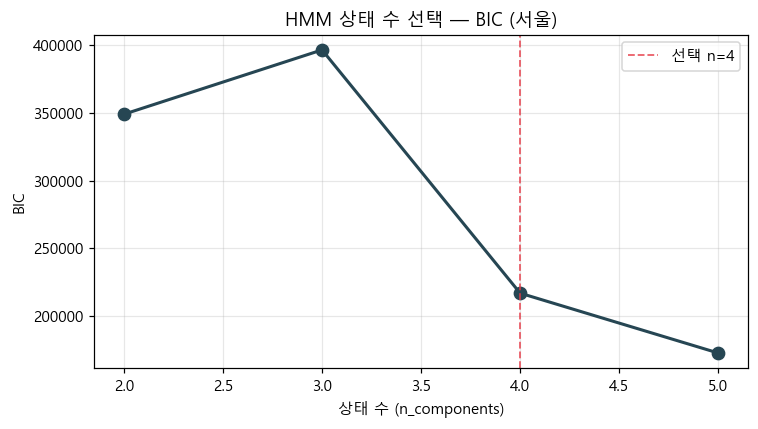

In [3]:
def fit_hmm(X_scaled, n_components, n_iter=200, seed=SEED):
    """GaussianHMM 학습 (diag covariance)"""
    model = GaussianHMM(
        n_components    = n_components,
        covariance_type = 'diag',
        n_iter          = n_iter,
        random_state    = seed,
    )
    model.fit(X_scaled)
    return model


def compute_bic(model, X_scaled):
    """BIC = -2·logL + k·ln(n)"""
    n, d = X_scaled.shape
    n_c  = model.n_components
    k    = (n_c - 1) * 2 + n_c * d * 2
    logL = model.score(X_scaled) * n
    return -2 * logL + k * np.log(n)


# 서울 데이터로 n_components=2~5 BIC 비교
seoul = df_hmm[df_hmm['시도'] == '서울'].sort_values('ym').reset_index(drop=True)
scaler_seoul = StandardScaler()
X_seoul = scaler_seoul.fit_transform(seoul[HMM_FEATURES].values)

bic_results = []
for n in range(2, 6):
    model = fit_hmm(X_seoul, n)
    bic   = compute_bic(model, X_seoul)
    ll    = model.score(X_seoul) * len(X_seoul)
    bic_results.append({'n_states': n, 'logL': round(ll, 2), 'BIC': round(bic, 2)})

bic_df = pd.DataFrame(bic_results)
print('서울 HMM BIC (낮을수록 좋음):')
print(bic_df.to_string(index=False))

bic_best = int(bic_df.loc[bic_df['BIC'].idxmin(), 'n_states'])
# 경제적 해석 가능성: 최대 4개 상태 (버블/과열/정상1/정상2)
N_STATES = min(bic_best, 4)
print(f'\nBIC 최적={bic_best}  → 해석 가능성 적용 n_states={N_STATES}')

# BIC 시각화
fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(bic_df['n_states'], bic_df['BIC'], marker='o', color='#264653', lw=2, ms=8)
ax.axvline(N_STATES, color='#E63946', ls='--', lw=1.2, alpha=0.8, label=f'선택 n={N_STATES}')
ax.set_xlabel('상태 수 (n_components)')
ax.set_ylabel('BIC')
ax.set_title('HMM 상태 수 선택 — BIC (서울)', fontsize=12)
ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('notebooks/fig_hmm_01_bic.png', bbox_inches='tight')
plt.show()

---
## 3. 시도별 HMM 학습 & 상태 매핑

In [4]:
def map_states_to_regime(sub_df, states, n_states):
    """HMM 상태를 경제적 의미로 매핑 (YoY, PIR, 전세가율 기준)"""
    stats = []
    for s in range(n_states):
        mask = states == s
        if mask.sum() == 0: continue
        yoy    = sub_df.loc[mask, '매매중위_YoY'].mean()
        jeonse = sub_df.loc[mask, '전세가율'].mean()
        pir    = sub_df.loc[mask, 'PIR'].mean()
        # 버블 점수: YoY 높고 전세가율 낮을수록, PIR 높을수록
        score  = yoy - jeonse * 0.3 + pir * 1.5
        stats.append({'state': s, 'count': int(mask.sum()),
                      'avg_YoY': round(yoy,2), 'avg_jeonse': round(jeonse,2),
                      'avg_PIR': round(pir,2), 'bubble_score': round(score,2)})
    stats_df = pd.DataFrame(stats).sort_values('bubble_score', ascending=False)
    ranks    = stats_df['state'].tolist()
    if n_states >= 3:
        names = ['버블', '과열'] + ['정상'] * (n_states - 2)
    else:
        names = ['과열', '정상']
    return {ranks[i]: names[i] for i in range(len(ranks))}, stats_df


# ── 시도별 HMM 학습
hmm_models   = {}
hmm_scalers  = {}
results_list = []

for sido in SIDO_LIST:
    sub = df_hmm[df_hmm['시도'] == sido].sort_values('ym').reset_index(drop=True)

    scaler = StandardScaler()
    X      = scaler.fit_transform(sub[HMM_FEATURES].values)
    hmm_scalers[sido] = scaler

    model  = fit_hmm(X, N_STATES)
    states = model.predict(X)
    hmm_models[sido] = model

    state_map, stats_df = map_states_to_regime(sub, states, N_STATES)
    regime_labels = np.array([state_map[s] for s in states])

    print(f'\n[{sido}] 상태 매핑 (n={N_STATES}):')
    print(stats_df[['state','count','avg_YoY','avg_jeonse','avg_PIR','bubble_score']].to_string(index=False))
    print(f'  -> {state_map}')

    # 결과 저장 (피처 분포 시각화용 컬럼 포함)
    keep_cols = ['ym','시도','ym_dt','bubble_label',
                 '매매중위가격','매매중위_YoY','전세가율','PIR',
                 'base_rate','매매_vol12','bsi_realestate',
                 'recon_error','anomaly']
    sub_result = sub[keep_cols].copy()
    sub_result['hmm_state']  = states
    sub_result['hmm_regime'] = regime_labels
    results_list.append(sub_result)

result_df = pd.concat(results_list, ignore_index=True)
print(f'\n전체 결과 shape: {result_df.shape}')
print('\n레짐 분포:')
print(result_df.groupby(['시도', 'hmm_regime']).size().unstack(fill_value=0))


[서울] 상태 매핑 (n=4):
 state  count  avg_YoY  avg_jeonse  avg_PIR  bubble_score
     3     36    15.74       53.62    11.59         17.04
     0     44     8.71       54.63    11.86         10.12
     2     41    11.24       73.54     7.60          0.58
     1     35     4.53       69.49     6.84         -6.06
  -> {3: '버블', 0: '과열', 2: '정상', 1: '정상'}

[경기] 상태 매핑 (n=4):
 state  count  avg_YoY  avg_jeonse  avg_PIR  bubble_score
     2     24    20.26       69.74     5.57          7.69
     0     37     8.66       68.08     4.35         -5.25
     3     24     0.82       65.65     5.18        -11.11
     1     71     3.83       76.70     4.16        -12.93
  -> {2: '버블', 0: '과열', 3: '정상', 1: '정상'}



[인천] 상태 매핑 (n=4):
 state  count  avg_YoY  avg_jeonse  avg_PIR  bubble_score
     3     19    10.00       64.74     3.94         -3.51
     1     24    13.70       81.35     4.31         -4.25
     0     40     6.65       70.60     4.90         -7.18
     2     73     1.69       80.62     4.17        -16.25
  -> {3: '버블', 1: '과열', 0: '정상', 2: '정상'}

전체 결과 shape: (468, 15)

레짐 분포:
hmm_regime  과열  버블   정상
시도                     
경기          37  24   95
서울          44  36   76
인천          24  19  113


---
## 4. 상태 전이 행렬 시각화

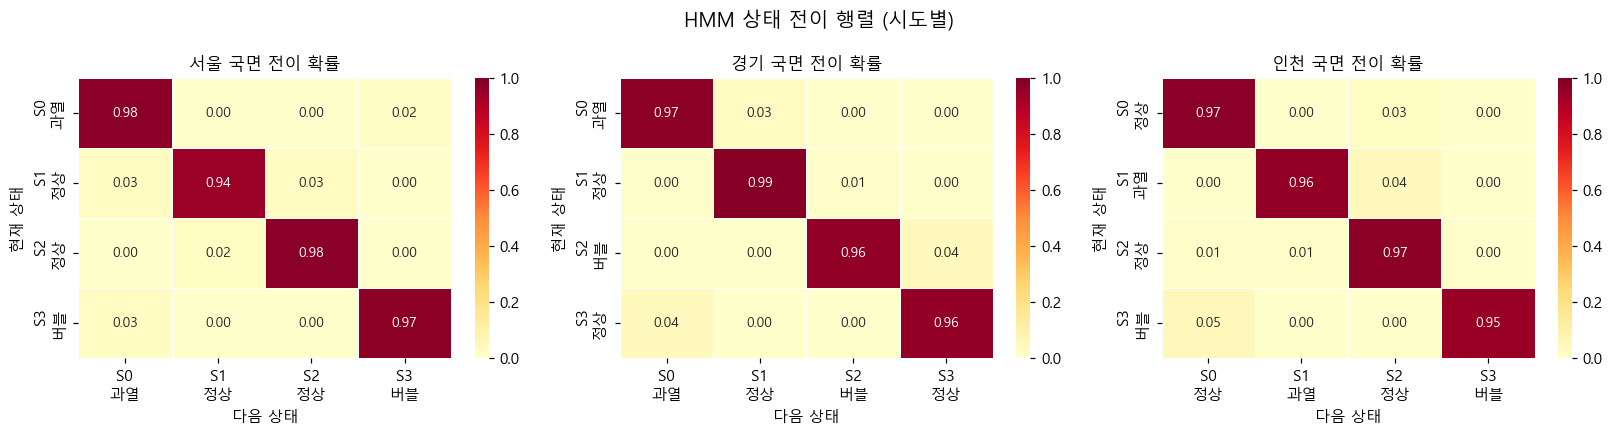

=== 전이 행렬 핵심 해석 ===

[서울]
  S0(과열): 자기 지속 확률 = 0.977
  S1(정상): 자기 지속 확률 = 0.943
  S2(정상): 자기 지속 확률 = 0.976
  S3(버블): 자기 지속 확률 = 0.972

[경기]
  S0(과열): 자기 지속 확률 = 0.972
  S1(정상): 자기 지속 확률 = 0.986
  S2(버블): 자기 지속 확률 = 0.958
  S3(정상): 자기 지속 확률 = 0.958

[인천]
  S0(정상): 자기 지속 확률 = 0.974
  S1(과열): 자기 지속 확률 = 0.959
  S2(정상): 자기 지속 확률 = 0.972
  S3(버블): 자기 지속 확률 = 0.947


In [5]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, sido in zip(axes, SIDO_LIST):
    model     = hmm_models[sido]
    sub       = result_df[result_df['시도'] == sido].sort_values('ym')
    states    = sub['hmm_state'].values

    # 레짐별 레이블 이름 구성
    unique_s  = sorted(np.unique(states))
    regime_map = {}
    for s in unique_s:
        mask = states == s
        regime_map[s] = sub.loc[sub['hmm_state'] == s, 'hmm_regime'].iloc[0]
    labels = [f"S{s}\n{regime_map[s]}" for s in unique_s]

    # 전이 행렬 (학습된 transmat_)
    trans = model.transmat_[np.ix_(unique_s, unique_s)]

    sns.heatmap(trans, annot=True, fmt='.2f',
                xticklabels=labels, yticklabels=labels,
                cmap='YlOrRd', vmin=0, vmax=1,
                linewidths=0.5, ax=ax, annot_kws={'size': 9})
    ax.set_title(f'{sido} 국면 전이 확률', fontsize=11)
    ax.set_xlabel('다음 상태')
    ax.set_ylabel('현재 상태')

plt.suptitle('HMM 상태 전이 행렬 (시도별)', fontsize=13)
plt.tight_layout()
plt.savefig('notebooks/fig_hmm_02_transmat.png', bbox_inches='tight')
plt.show()

# 전이 확률 해석 출력
print('=== 전이 행렬 핵심 해석 ===')
for sido in SIDO_LIST:
    model  = hmm_models[sido]
    sub    = result_df[result_df['시도'] == sido]
    print(f'\n[{sido}]')
    for s in range(N_STATES):
        regime = sub[sub['hmm_state']==s]['hmm_regime'].mode()
        regime = regime.iloc[0] if len(regime) > 0 else '?'
        stay   = model.transmat_[s, s]
        print(f'  S{s}({regime}): 자기 지속 확률 = {stay:.3f}')

---
## 5. 레짐 시계열 시각화

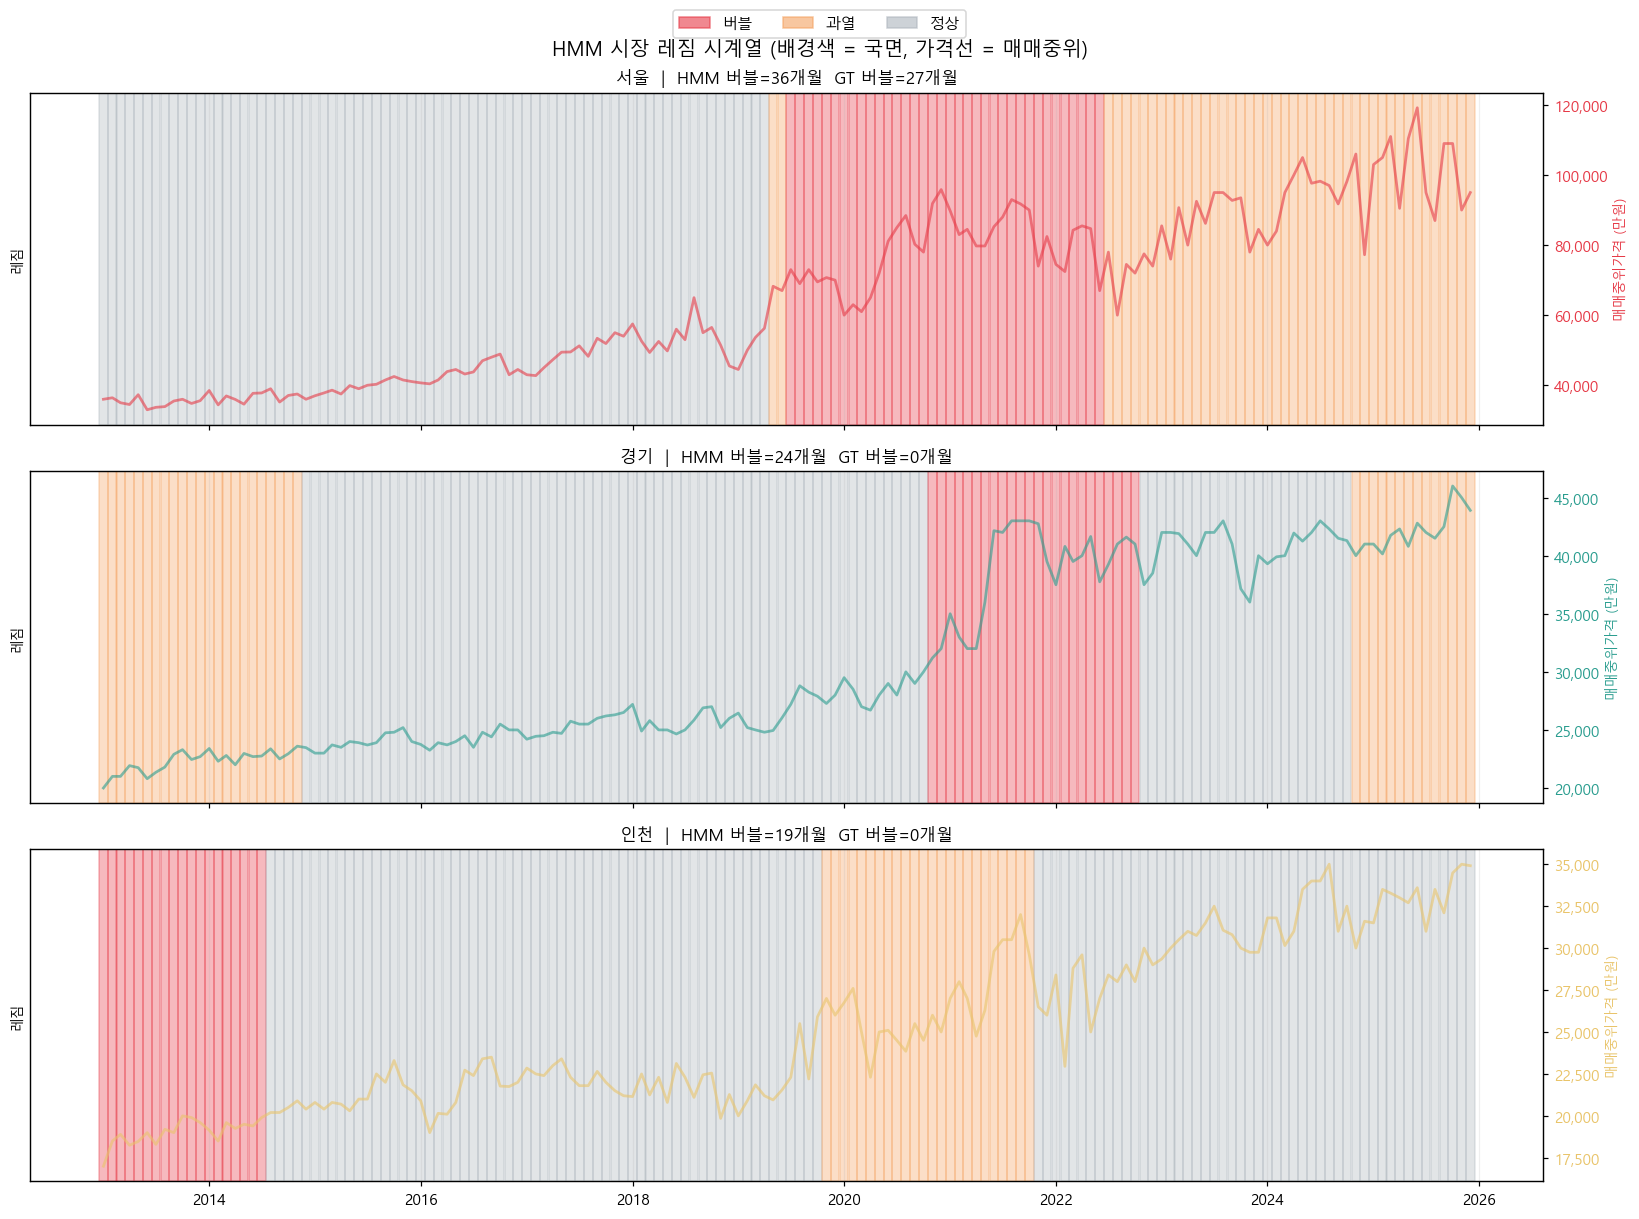

In [6]:
REGIME_COLORS = {'버블': '#E63946', '과열': '#F4A261', '정상': '#ADB5BD'}

fig, axes = plt.subplots(3, 1, figsize=(15, 11), sharex=True)

for ax, sido in zip(axes, SIDO_LIST):
    sub = result_df[result_df['시도'] == sido].sort_values('ym_dt')
    c   = SIDO_COLORS[sido]

    # 가격 라인
    ax2 = ax.twinx()
    ax2.plot(sub['ym_dt'], sub['매매중위가격'], color=c, lw=1.8, alpha=0.6, zorder=2)
    ax2.set_ylabel('매매중위가격 (만원)', color=c, fontsize=9)
    ax2.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'{x:,.0f}'))
    ax2.tick_params(axis='y', labelcolor=c)

    # 레짐 배경색
    regimes   = sub['hmm_regime'].values
    ym_dts    = sub['ym_dt'].values
    for i in range(len(sub)):
        col = REGIME_COLORS.get(regimes[i], '#EEEEEE')
        ax.axvspan(ym_dts[i] - pd.Timedelta(days=15),
                   ym_dts[i] + pd.Timedelta(days=15),
                   alpha=0.35, color=col, zorder=0)

    # bubble_label=2 외곽선 표시
    for _, row in sub[sub['bubble_label'] == 2].iterrows():
        ax.axvspan(row['ym_dt'] - pd.Timedelta(days=15),
                   row['ym_dt'] + pd.Timedelta(days=15),
                   alpha=0, edgecolor='#E63946', lw=2, fill=False, zorder=3)

    ax.set_ylabel('레짐', fontsize=9)
    ax.set_yticks([])

    b_cnt = int((sub['bubble_label'] == 2).sum())
    hmm_b = int((sub['hmm_regime'] == '버블').sum())
    ax.set_title(f'{sido}  |  HMM 버블={hmm_b}개월  GT 버블={b_cnt}개월', fontsize=11)
    ax.grid(axis='x', alpha=0.2)

# 범례
patches = [mpatches.Patch(color=c, label=r, alpha=0.6)
           for r, c in REGIME_COLORS.items()]
fig.legend(handles=patches, loc='upper center', ncol=3, fontsize=10,
           bbox_to_anchor=(0.5, 1.01))
plt.suptitle('HMM 시장 레짐 시계열 (배경색 = 국면, 가격선 = 매매중위)', fontsize=13)
plt.tight_layout()
plt.savefig('notebooks/fig_hmm_03_regime_ts.png', bbox_inches='tight')
plt.show()

---
## 6. LSTM-AE vs HMM 비교 & 성능 평가

=== HMM: 버블(2) 탐지 성능 ===
              precision    recall  f1-score   support

         비버블      0.959     0.864     0.909       405
          버블      0.179     0.444     0.255        27

    accuracy                          0.838       432
   macro avg      0.569     0.654     0.582       432
weighted avg      0.910     0.838     0.868       432

=== LSTM-AE: 버블(2) 탐지 성능 ===
              precision    recall  f1-score   support

         비버블      1.000     0.632     0.775       405
          버블      0.153     1.000     0.266        27

    accuracy                          0.655       432
   macro avg      0.577     0.816     0.520       432
weighted avg      0.947     0.655     0.743       432



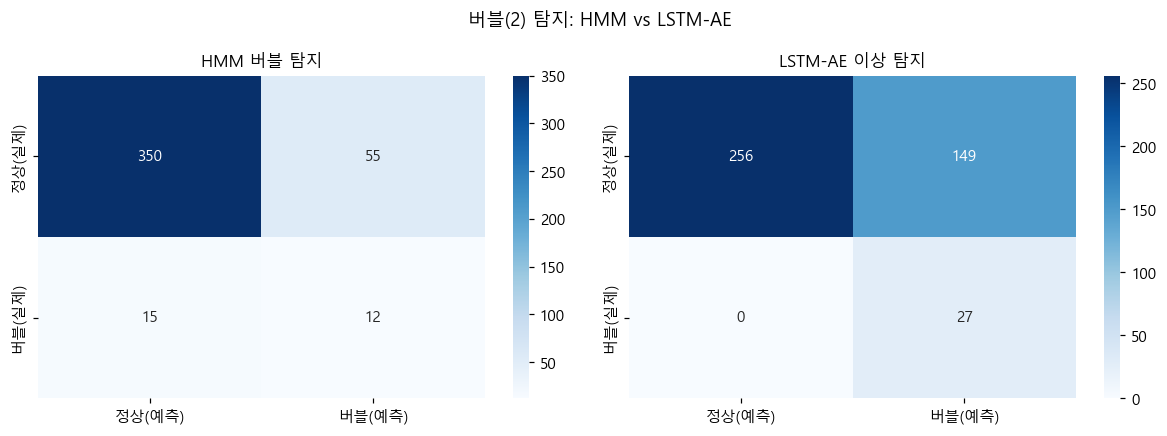


[AND 앙상블] HMM-버블 AND LSTM-이상:
  탐지 건수: 57  Precision=0.211  Recall=0.444
  (Precision 개선: LSTM-AE 0.407 -> AND 0.211)


In [7]:
from sklearn.metrics import classification_report, roc_auc_score

eval_df   = result_df[result_df['bubble_label'].notna()].copy()
y_true_b2 = (eval_df['bubble_label'] == 2).astype(int)
y_hmm_b2  = (eval_df['hmm_regime'] == '버블').astype(int)
y_ae_b2   = eval_df['anomaly'].fillna(0).astype(int)

print('=== HMM: 버블(2) 탐지 성능 ===')
print(classification_report(y_true_b2, y_hmm_b2,
                              target_names=['비버블','버블'], digits=3, zero_division=0))

print('=== LSTM-AE: 버블(2) 탐지 성능 ===')
print(classification_report(y_true_b2, y_ae_b2,
                              target_names=['비버블','버블'], digits=3, zero_division=0))

# 혼동 행렬
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
for ax, (y_pred, title) in zip(axes, [
    (y_hmm_b2, 'HMM 버블 탐지'),
    (y_ae_b2,  'LSTM-AE 이상 탐지'),
]):
    from sklearn.metrics import confusion_matrix
    cm = confusion_matrix(y_true_b2, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=['정상(예측)','버블(예측)'],
                yticklabels=['정상(실제)','버블(실제)'])
    ax.set_title(title, fontsize=11)
plt.suptitle('버블(2) 탐지: HMM vs LSTM-AE', fontsize=12)
plt.tight_layout()
plt.savefig('notebooks/fig_hmm_04_compare.png', bbox_inches='tight')
plt.show()

# 앙상블 AND 결과
both = (y_hmm_b2 == 1) & (y_ae_b2 == 1)
bp = ((eval_df['bubble_label']==2) & both).sum() / max(1, both.sum())
br = ((eval_df['bubble_label']==2) & both).sum() / max(1, y_true_b2.sum())
print(f'\n[AND 앙상블] HMM-버블 AND LSTM-이상:')
print(f'  탐지 건수: {both.sum()}  Precision={bp:.3f}  Recall={br:.3f}')
print(f'  (Precision 개선: LSTM-AE {y_ae_b2.mean():.3f} -> AND {bp:.3f})')

---
## 7. 국면별 피처 분포 (Emission 파라미터)

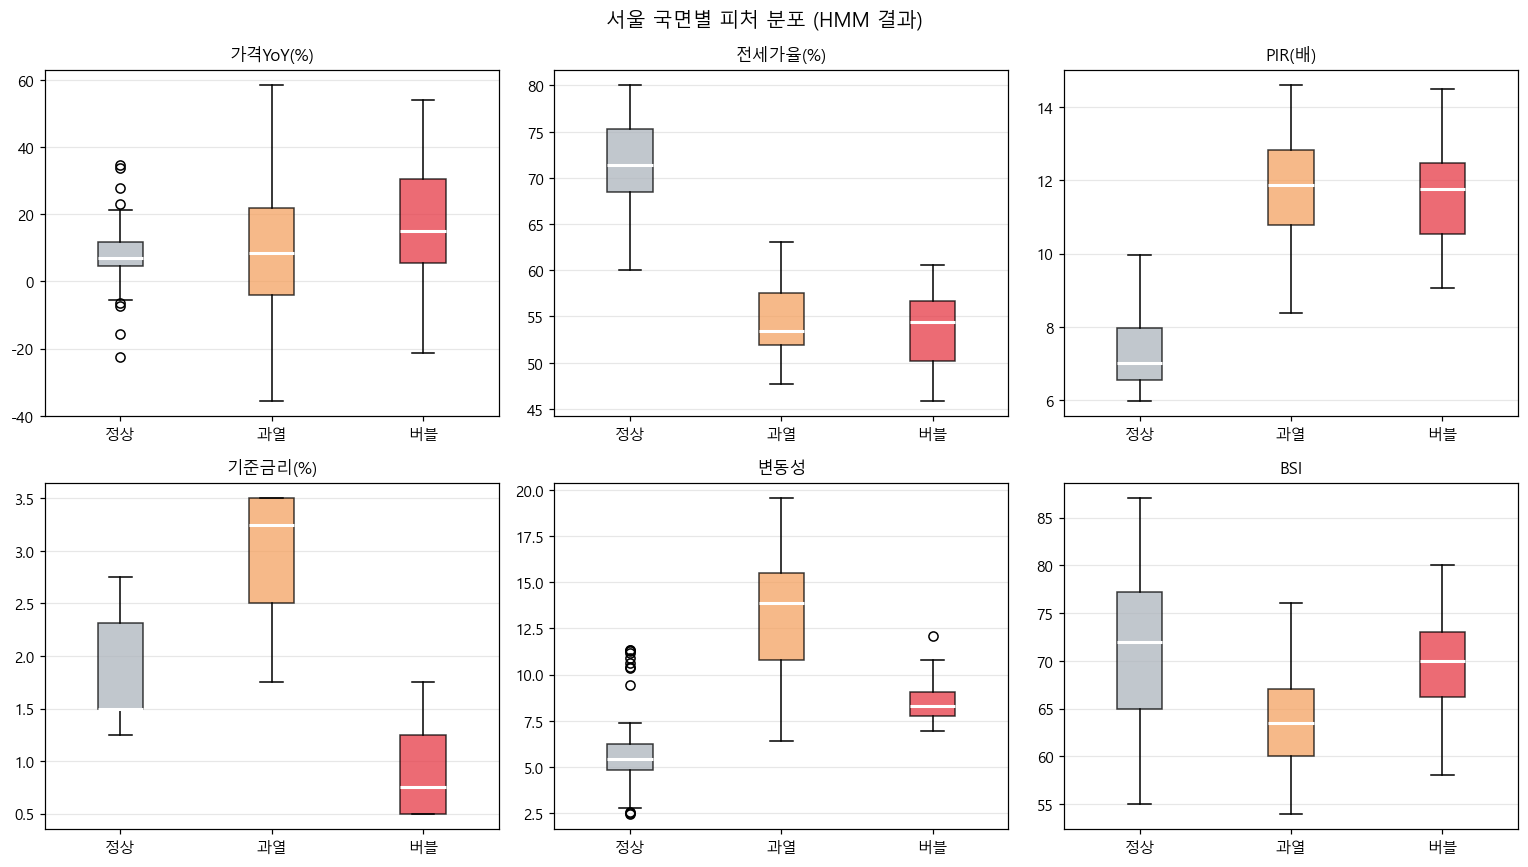

=== 서울 국면별 평균 수치 ===
            매매중위_YoY   전세가율    PIR  base_rate  매매_vol12
hmm_regime                                             
과열              8.71  54.63  11.86       3.05     13.20
버블             15.74  53.62  11.59       0.91      8.51
정상              8.15  71.67   7.25       1.79      5.69


In [8]:
# 서울 각 국면별 핵심 피처 분포 박스플롯
seoul_res = result_df[result_df['시도'] == '서울'].copy()
plot_features = ['매매중위_YoY', '전세가율', 'PIR', 'base_rate', '매매_vol12', 'bsi_realestate']
feat_labels   = ['가격YoY(%)', '전세가율(%)', 'PIR(배)', '기준금리(%)', '변동성', 'BSI']

regime_order  = ['정상', '과열', '버블']
regime_palette = {'정상': '#ADB5BD', '과열': '#F4A261', '버블': '#E63946'}

fig, axes = plt.subplots(2, 3, figsize=(14, 8))
for ax, feat, label in zip(axes.flatten(), plot_features, feat_labels):
    # 레짐별 분포
    data_by_regime = [
        seoul_res[seoul_res['hmm_regime'] == r][feat].dropna().values
        for r in regime_order if r in seoul_res['hmm_regime'].unique()
    ]
    valid_regimes = [r for r in regime_order if r in seoul_res['hmm_regime'].unique()]
    colors_used   = [regime_palette[r] for r in valid_regimes]

    bp = ax.boxplot(data_by_regime, patch_artist=True, notch=False,
                    medianprops=dict(color='white', lw=2))
    for patch, color in zip(bp['boxes'], colors_used):
        patch.set_facecolor(color)
        patch.set_alpha(0.75)

    ax.set_xticklabels(valid_regimes, fontsize=10)
    ax.set_title(label, fontsize=11)
    ax.grid(axis='y', alpha=0.3)

plt.suptitle('서울 국면별 피처 분포 (HMM 결과)', fontsize=13)
plt.tight_layout()
plt.savefig('notebooks/fig_hmm_05_feature_dist.png', bbox_inches='tight')
plt.show()

# 국면별 평균 수치
print('=== 서울 국면별 평균 수치 ===')
summary = (seoul_res.groupby('hmm_regime')
           [['매매중위_YoY','전세가율','PIR','base_rate','매매_vol12']].mean()
           .round(2))
print(summary.to_string())

---
## 8. 결과 저장 & 요약

In [9]:
# ── lstm_ae_scores.csv에 HMM 결과 병합 후 저장
base_df  = pd.read_csv('data/processed/lstm_ae_scores.csv', encoding=ENC)
merge_cols = result_df[['ym', '시도', 'hmm_state', 'hmm_regime']]
save_df    = base_df.merge(merge_cols, on=['ym', '시도'], how='left')

out_path = 'data/processed/hmm_regime.csv'
save_df.to_csv(out_path, index=False, encoding='utf-8-sig')
print(f'저장: {out_path}  shape={save_df.shape}')
print(f'새 컬럼: hmm_state, hmm_regime')

# ── 요약
print()
print('=' * 60)
print('  HMM 레짐 탐지 요약')
print('=' * 60)

print(f'\n[모델 설정]')
print(f'  n_components : {N_STATES}  (BIC 최적)')
print(f'  covariance   : diag')
print(f'  피처 수      : {len(HMM_FEATURES)}개')
print(f'  학습 방식    : 시도별 독립 HMM (Full sequence)')

print(f'\n[시도별 국면 분포]')
for sido in SIDO_LIST:
    sub = result_df[result_df['시도'] == sido]
    dist = sub['hmm_regime'].value_counts().to_dict()
    print(f'  {sido}: {dist}')

print(f'\n[버블 탐지 성능]')
eval_ = result_df[result_df['bubble_label'].notna()]
y_t   = (eval_['bubble_label'] == 2).astype(int)
y_h   = (eval_['hmm_regime'] == '버블').astype(int)
from sklearn.metrics import precision_score, recall_score, f1_score
print(f'  HMM    — Precision={precision_score(y_t,y_h,zero_division=0):.3f}'
      f'  Recall={recall_score(y_t,y_h,zero_division=0):.3f}'
      f'  F1={f1_score(y_t,y_h,zero_division=0):.3f}')
y_a = eval_['anomaly']
print(f'  LSTM-AE — Precision={precision_score(y_t,y_a,zero_division=0):.3f}'
      f'  Recall={recall_score(y_t,y_a,zero_division=0):.3f}'
      f'  F1={f1_score(y_t,y_a,zero_division=0):.3f}')

both = (y_h==1) & (y_a==1)
both_prec = ((eval_['bubble_label']==2) & both).sum() / max(1, both.sum())
both_rec  = ((eval_['bubble_label']==2) & both).sum() / max(1, y_t.sum())
print(f'  AND 앙상블 — Precision={both_prec:.3f}  Recall={both_rec:.3f}')

print(f'\n[저장 파일]')
print(f'  data/processed/hmm_regime.csv')
print(f'  notebooks/fig_hmm_01~05.png')
print('=' * 60)

저장: data/processed/hmm_regime.csv  shape=(468, 47)
새 컬럼: hmm_state, hmm_regime

  HMM 레짐 탐지 요약

[모델 설정]
  n_components : 4  (BIC 최적)
  covariance   : diag
  피처 수      : 7개
  학습 방식    : 시도별 독립 HMM (Full sequence)

[시도별 국면 분포]
  서울: {'정상': 76, '과열': 44, '버블': 36}
  경기: {'정상': 95, '과열': 37, '버블': 24}
  인천: {'정상': 113, '과열': 24, '버블': 19}

[버블 탐지 성능]
  HMM    — Precision=0.179  Recall=0.444  F1=0.255
  LSTM-AE — Precision=0.153  Recall=1.000  F1=0.266
  AND 앙상블 — Precision=0.211  Recall=0.444

[저장 파일]
  data/processed/hmm_regime.csv
  notebooks/fig_hmm_01~05.png
